# 🚍🚆🚊 Transit Equity in Montreal
## Do we serve everyone equally? A spatial analysis of STM, STL and RTL service *vs.* neighbourhood demographics.

**Author:** Bruna Bado  
**Last updated:** June 2026  
**Data sources:** STM, STL, RTL GTFS Static Feeds & Statistics Canada 2021 Census

---

## Abstract

Transit agencies are often evaluated on punctuality. But a harder and more important question is whether service runs *where it matters most*.

This analysis examines transit equity across the inner Montreal Census Metropolitan Area (CMA) by measuring the relationship between transit service levels and the socioeconomic characteristics of each neighbourhood.

First, we combine GTFS schedule data from 3 urban transit agencies: the STM (island of Montreal), STL (Laval) and RTL (Longueuil and inner South Shore). Then, we overlay it onto 2021 Census tract demographics. Together these agencies cover the densely populated urban core of the CMA with comparable, bus-oriented service networks, making inter-agency comparisons methodologically sound.

>**Scope note:**
>* exo's outer-suburb network (Couronnes Nord and Sud) and the REM are not included. exo's commuter rail operates a peak-hours model that is methodologically incompatible with headway-based urban service metrics. Additionally, its bus network spans 10+ separate GTFS feeds requiring significant additional harmonization.
>* A full-CMA analysis is a natural extension of this work.

**Research questions:**
1. Which Montreal CMA Census Tracts have the least transit service, measured by stop density and weekly trip frequency?
2. Are low-service areas correlated with lower median income, higher proportions of visible minorities, or higher rates of low income?
3. Which patterns emerge that could inform transit equity policy?

*All data used in this analysis is publicly available.*

---

## 1. Setup

In [323]:
# Standard library ──────────────────────────────────────────────────────────
import os
import zipfile
import warnings
warnings.filterwarnings('ignore')

# Network ────────────────────────────────────────────────────────────────────
import requests

# Data manipulation ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# Geospatial ─────────────────────────────────────────────────────────────────
import geopandas as gpd
from shapely.geometry import Point

# Visualization ──────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import folium
from folium.plugins import HeatMap
from branca.colormap import linear

# Statistics ─────────────────────────────────────────────────────────────────
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Display settings ───────────────────────────────────────────────────────────
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
sns.set_theme(style='whitegrid', palette='muted')

# File paths (relative to the notebooks/ directory) ─────────────────────────
DATA_RAW       = os.path.join('..', 'data', 'raw')
DATA_PROCESSED = os.path.join('..', 'data', 'processed')
FIGURES        = os.path.join('..', 'figures')

for path in [DATA_RAW, DATA_PROCESSED, FIGURES,
             os.path.join(DATA_RAW, 'gtfs_stm'),
             os.path.join(DATA_RAW, 'gtfs_stl'),   # ← new
             os.path.join(DATA_RAW, 'gtfs_rtl'),   # ← new
             os.path.join(DATA_RAW, 'census')]:
    os.makedirs(path, exist_ok=True)

print("✅ All libraries loaded successfully.")
print(f"   Working directory: {os.getcwd()}")

✅ All libraries loaded successfully.
   Working directory: c:\Users\bruna\Documents\Data Analysis\transit-equity-montreal\notebooks


---

## 2. Data Sources

This analysis relies on five publicly available datasets:

| # | Source | Description | Format | Geography |
|---|--------|-------------|--------|-----------|
| 1 | **STM GTFS** | Scheduled routes, stops, and trip frequencies (island of Montreal) | ZIP of CSVs | Stop-level |
| 2 | **STL GTFS** | Scheduled routes, stops, and trip frequencies (Laval) | ZIP of CSVs | Stop-level |
| 3 | **RTL GTFS** | Scheduled routes, stops, and trip frequencies (Longueuil and inner South Shore) | ZIP of CSVs | Stop-level |
| 4 | **StatsCan 2021 Census – Boundaries** | Geographic boundaries for Census Tracts in the Montreal CMA | Shapefile | Census Tract |
| 5 | **StatsCan 2021 Census – Profile** | Demographic, income, and socioeconomic indicators | CSV | Census Tract |

### Why these specific agencies?

The STM, STL and RTL collectively serve the inner urban core of the Montreal CMA with comparable, bus-oriented networks. All 3 publish open GTFS feeds and operate frequent, all-day service, making their headway and trip-frequency metrics directly comparable. Their combined service area covers the vast majority of the CMA's densely populated Census Tracts.

### What is GTFS?
GTFS (General Transit Feed Specification) is an open standard used worldwide by transit agencies to publish scheduled timetables. A GTFS feed is a ZIP archive of inter-related CSV tables: routes, trips, stops, stop times, and calendar data. It is the same format that apps like Transit use to show riders when the next bus arrives. This analysis uses the **static** GTFS feed (scheduled timetable) for each agency.

### What is a Census Tract?
Census Tracts (CTs) are small, stable geographic units designed by Statistics Canada to have populations of roughly 2,500-8,000 people. They are the finest-grained geography at which StatsCan publishes full demographic and income breakdowns, making them ideal for neighbourhood-level equity analysis.

>**Data currency note:**
>* The GTFS feeds represent current scheduled service as of June 2026.
>* Census data is from the 2021 long-form census, which remains the most granular and reliable public source for the socioeconomic indicators used here. Demographic shifts since 2021 may affect some findings.

---

## 3. Data Loading and Preprocessing

### 3.1 GTFS - STM, STL and RTL

We download and parse GTFS schedule feeds from all 3 agencies. Because each feed uses its own internal ID numbering (stop IDs, trip IDs, etc.), we prefix every ID with the agency code (`STM_`, `STL_`, `RTL_`) before merging. This prevents ID collisions while preserving the ability to filter by agency at any point in the analysis.

In [324]:
# Reusable download helper ───────────────────────────────────────────────────

     # It downloads a file from `url` to `dest_path`. It skips if the file already exists, so it's safe to re-run.

def download_file(url: str, dest_path: str, label: str = "") -> bool:

    if os.path.exists(dest_path):
        size_mb = os.path.getsize(dest_path) / 1_048_576
        print(f"✅ {label} already exists ({size_mb:.1f} MB)... Skipping file.")
        return True

    print(f"⬇️  Downloading {label} ...")
    try:
        r = requests.get(url, stream=True, timeout=120)
        r.raise_for_status()
        total = int(r.headers.get('content-length', 0))
        downloaded = 0
        with open(dest_path, 'wb') as f:
            for chunk in r.iter_content(chunk_size=65_536):
                f.write(chunk)
                downloaded += len(chunk)
                if total:
                    print(f"\r   {downloaded / total * 100:5.1f}%  "
                          f"({downloaded/1_048_576:.1f} / {total/1_048_576:.1f} MB)",
                          end="")
        print(f"\n✅ Saved to: {dest_path}")
        return True
    except Exception as e:
        print(f"\n❌ Download failed: {e}")
        if os.path.exists(dest_path):
            os.remove(dest_path)   # remove partial download
        return False

In [325]:
# GTFS agency definitions ────────────────────────────────────────────────────

     # Each agency entry contains:
     #   url            : direct download link for the GTFS ZIP
     #   path           : where we save it locally
     #   open_data_page : fallback URL if auto-download fails

AGENCIES = {
    'STM': {
        'url' : 'https://www.stm.info/sites/default/files/gtfs/gtfs_stm.zip',
        'path': os.path.join(DATA_RAW, 'gtfs_stm', 'gtfs_stm.zip'),
        'open_data_page': 'https://www.stm.info/en/about/developers',
    },
    'STL': {
        'url' : None,   # direct download not available; manual only (see below)
        'path': os.path.join(DATA_RAW, 'gtfs_stl', 'gtfs_stl.zip'),
        'open_data_page': 'https://stlaval.ca/about-us/public-information/open-data',
    },
    'RTL': {
        'url' : 'https://www.rtl-longueuil.qc.ca/transit/latestfeed/RTL.zip',
        'path': os.path.join(DATA_RAW, 'gtfs_rtl', 'gtfs_rtl.zip'),
        'open_data_page': 'https://www.rtl-longueuil.qc.ca/en-CA/open-data/',
    },
}

# Download all 3 feeds ───────────────────────────────────────────────────

download_failures = []

for code, info in AGENCIES.items():
    print(f"\n{code} {'─'*56}")

    if info['url'] is None:
        # Manual-only agency (check if file is already present)
        if os.path.exists(info['path']):
            size_mb = os.path.getsize(info['path']) / 1_048_576
            print(f"✅ {code} GTFS feed already exists ({size_mb:.1f} MB)... Skipping file.")
        else:
            print(f"⚠️  {code}: manual download required.")
            print(f"    1. Go to: {info['open_data_page']}")
            print(f"    2. Download the GTFS static feed (.zip)")
            print(f"    3. Save it as: {info['path']}")
            download_failures.append(code)
    else:
        success = download_file(info['url'], info['path'], label=f"{code} GTFS feed")
        if not success:
            download_failures.append(code)

if download_failures:
    print(f"\n⛔ Fix the above before running the next cell.")
else:
    print(f"\n{'─'*60}")
    print("✅ All three GTFS feeds ready.")


STM ────────────────────────────────────────────────────────
✅ STM GTFS feed already exists (57.1 MB)... Skipping file.

STL ────────────────────────────────────────────────────────
✅ STL GTFS feed already exists (2.6 MB)... Skipping file.

RTL ────────────────────────────────────────────────────────
✅ RTL GTFS feed already exists (5.6 MB)... Skipping file.

────────────────────────────────────────────────────────────
✅ All three GTFS feeds ready.


In [326]:
# Multi-agency GTFS loader ───────────────────────────────────────────────────

     # This function loads GTFS tables from a single ZIP and:
     #   1. Tags every row with the agency code.
     #   2. Prefixes all IDs (stop_id, trip_id, route_id, service_id) with the agency code so merged tables have globally unique IDs.
     #   3. Adds default values for optional columns that not all feeds include (location_type, pickup_type), so concatenation doesn't produce NaNs.

def load_and_tag_gtfs(zip_path: str, agency_code: str) -> tuple:
    """
    Load and tag GTFS tables from zip_path for a given agency_code.
    Returns: (stops, routes, trips, stop_times, calendar)
    """
    pfx = agency_code + '_'

    # Verify the file is actually a ZIP before trying to open it
    if not zipfile.is_zipfile(zip_path):
        raise ValueError(
            f"{agency_code}: File at {zip_path} is not a valid ZIP.\n"
            f"It may have been downloaded incorrectly (e.g. an HTML error page).\n"
            f"Delete the file, download it manually, and re-run."
        )
    
    with zipfile.ZipFile(zip_path, 'r') as z:
        available = set(z.namelist())

        stops_df   = pd.read_csv(z.open('stops.txt'))
        routes_df  = pd.read_csv(z.open('routes.txt'))
        trips_df   = pd.read_csv(z.open('trips.txt'))
        st_df      = pd.read_csv(z.open('stop_times.txt'),
                                  dtype={'arrival_time': str,
                                         'departure_time': str})

        # calendar.txt is required by GTFS spec but some feeds use only calendar_dates.txt (we can use whichever is available)
        if 'calendar.txt' in available:
            cal_df = pd.read_csv(z.open('calendar.txt'))
        else:
            raise FileNotFoundError(
                f"{agency_code}: calendar.txt not found. "
                f"Available files: {available}"
            )

    # Add agency identifier to all tables ───────────────────────────────────
    
    for df in [stops_df, routes_df, trips_df, st_df, cal_df]:
        df['agency'] = agency_code

    # Ensure optional columns exist with sensible defaults ──────────────────
    
    # location_type: 0 = boarding stop
    if 'location_type' not in stops_df.columns:
        stops_df['location_type'] = 0
    else:
        stops_df['location_type'] = stops_df['location_type'].fillna(0).astype(int)

    # pickup_type: 0 = regular pickup
    if 'pickup_type' not in st_df.columns:
        st_df['pickup_type'] = 0
    else:
        st_df['pickup_type'] = st_df['pickup_type'].fillna(0).astype(int)

    # Prefix all IDs with agency code ───────────────────────────────────────
    
    stops_df['stop_id']    = pfx + stops_df['stop_id'].astype(str)

    routes_df['route_id']  = pfx + routes_df['route_id'].astype(str)

    trips_df['trip_id']    = pfx + trips_df['trip_id'].astype(str)
    trips_df['route_id']   = pfx + trips_df['route_id'].astype(str)
    trips_df['service_id'] = pfx + trips_df['service_id'].astype(str)

    st_df['trip_id']       = pfx + st_df['trip_id'].astype(str)
    st_df['stop_id']       = pfx + st_df['stop_id'].astype(str)

    cal_df['service_id']   = pfx + cal_df['service_id'].astype(str)

    return stops_df, routes_df, trips_df, st_df, cal_df

# Load all 3 agencies ────────────────────────────────────────────────────

print("📂 Loading GTFS tables for all agencies...\n")

all_stops, all_routes, all_trips, all_stop_times, all_calendar = [], [], [], [], []

for code, info in AGENCIES.items():
    print(f"{code} {'─'*25}")
    s, r, t, st, cal = load_and_tag_gtfs(info['path'], code)
    all_stops.append(s)
    all_routes.append(r)
    all_trips.append(t)
    all_stop_times.append(st)
    all_calendar.append(cal)
    print(f"    stops      : {len(s):>9,}")
    print(f"    routes     : {len(r):>9,}")
    print(f"    trips      : {len(t):>9,}")
    print(f"    stop_times : {len(st):>9,}")
    print(f"    calendar   : {len(cal):>9,}")

# Concatenate into single tables ────────────────────────────────────────────

stops      = pd.concat(all_stops,      ignore_index=True)
routes     = pd.concat(all_routes,     ignore_index=True)
trips      = pd.concat(all_trips,      ignore_index=True)
stop_times = pd.concat(all_stop_times, ignore_index=True)
calendar   = pd.concat(all_calendar,   ignore_index=True)

print(f"\n{'─'*50}")
print(f"✅ Combined tables:")
print(f"    stops      : {len(stops):>9,}  (unique IDs: {stops['stop_id'].nunique():,})")
print(f"    routes     : {len(routes):>9,}  (unique IDs: {routes['route_id'].nunique():,})")
print(f"    trips      : {len(trips):>9,}  (unique IDs: {trips['trip_id'].nunique():,})")
print(f"    stop_times : {len(stop_times):>9,}")
print(f"    calendar   : {len(calendar):>9,}")
print(f"\nAgency breakdown:")
print(stops.groupby('agency').size().rename('stop_count').to_frame())

📂 Loading GTFS tables for all agencies...

STM ─────────────────────────
    stops      :     9,188
    routes     :       231
    trips      :   203,056
    stop_times : 7,151,705
    calendar   :       132
STL ─────────────────────────
    stops      :     2,845
    routes     :       102
    trips      :     5,333
    stop_times :   337,862
    calendar   :         3
RTL ─────────────────────────
    stops      :     3,287
    routes     :       152
    trips      :    13,759
    stop_times :   495,738
    calendar   :         5

──────────────────────────────────────────────────
✅ Combined tables:
    stops      :    15,320  (unique IDs: 15,320)
    routes     :       485  (unique IDs: 485)
    trips      :   222,148  (unique IDs: 222,148)
    stop_times : 7,985,305
    calendar   :       140

Agency breakdown:
        stop_count
agency            
RTL           3287
STL           2845
STM           9188


In [327]:
# Inspect the combined GTFS tables ──────────────────────────────────────────

for name, df in [('STOPS', stops), ('ROUTES', routes),
                  ('TRIPS', trips), ('STOP_TIMES', stop_times),
                  ('CALENDAR', calendar)]:
    print(f"\n{name} {'─'*(52-len(name))}")
    print(f"   shape  : {df.shape}")
    print(f"   agencies in table: {sorted(df['agency'].unique())}")
    display(df.head(3))


STOPS ───────────────────────────────────────────────
   shape  : (15320, 12)
   agencies in table: ['RTL', 'STL', 'STM']


,stop_id,stop_code,stop_name,stop_lat,stop_lon,stop_url,location_type,parent_station,wheelchair_boarding,agency,stop_display,stop_abribus
0,STM_STATION_M118,10118,STATION ANGRIGNON,45.45,-73.60,NaN,1,NaN,1.00,STM,NaN,NaN
1,STM_43,10118,Station Angrignon,45.45,-73.60,https://www.stm.info/fr/infos/reseaux/metro/an...,0,STATION_M118,1.00,STM,NaN,NaN
2,STM_43-01,10118,Station Angrignon,45.45,-73.60,NaN,2,STATION_M118,1.00,STM,NaN,NaN



ROUTES ──────────────────────────────────────────────
   shape  : (485, 12)
   agencies in table: ['RTL', 'STL', 'STM']


,route_id,agency_id,route_short_name,route_long_name,route_type,route_url,route_color,route_text_color,route_desc,route_desc_detail,agency,route_headsign
0,STM_1,STM,1,Ligne 1 - Verte,1,https://www.stm.info/fr/infos/reseaux/metro/li...,00B300,FFFFFF,NaN,NaN,STM,NaN
1,STM_2,STM,2,Ligne 2 - Orange,1,https://www.stm.info/fr/infos/reseaux/metro/li...,D95700,FFFFFF,NaN,NaN,STM,NaN
2,STM_4,STM,4,Ligne 4 - Jaune,1,https://www.stm.info/fr/infos/reseaux/metro/li...,FFD900,000000,NaN,NaN,STM,NaN



TRIPS ───────────────────────────────────────────────
   shape  : (222148, 10)
   agencies in table: ['RTL', 'STL', 'STM']


,route_id,service_id,trip_id,trip_headsign,direction_id,shape_id,wheelchair_accessible,route_pattern_id,agency,block_id
0,STM_1,STM_26M-GLOBAUX-02-S,STM_296382552,Station Honoré-Beaugrand,0.00,1_1071,1,1_1071,STM,NaN
1,STM_1,STM_26M-GLOBAUX-02-S,STM_296382555,Station Angrignon,1.00,1_1072,1,1_1072,STM,NaN
2,STM_1,STM_26M-GLOBAUX-02-S,STM_296382558,Station Honoré-Beaugrand,0.00,1_1071,1,1_1071,STM,NaN



STOP_TIMES ──────────────────────────────────────────
   shape  : (7985305, 11)
   agencies in table: ['RTL', 'STL', 'STM']


,trip_id,arrival_time,departure_time,stop_id,stop_sequence,pickup_type,agency,drop_off_type,stop_headsign,shape_dist_traveled,timepoint
0,STM_295375000,05:58:00,05:58:00,STM_55545,1,0,STM,NaN,NaN,NaN,NaN
1,STM_295375000,05:58:15,05:58:15,STM_55568,2,0,STM,NaN,NaN,NaN,NaN
2,STM_295375000,05:59:07,05:59:07,STM_55584,3,0,STM,NaN,NaN,NaN,NaN



CALENDAR ────────────────────────────────────────────
   shape  : (140, 11)
   agencies in table: ['RTL', 'STL', 'STM']


,service_id,monday,tuesday,wednesday,thursday,friday,saturday,sunday,start_date,end_date,agency
0,STM_26M-GLOBAUX-02-S,1,1,1,1,1,0,0,20260323,20260612,STM
1,STM_26M-H50M000S-70-S,1,1,1,1,1,0,0,20260323,20260515,STM
2,STM_26M-H50M000S-70-SV,0,0,0,0,1,0,0,20260323,20260515,STM


### 3.2. Census Tract Boundaries

In [328]:
# Download Census Tract boundary shapefile (Canada, 2021) ───────────────────

     # The "lct" file contains Census Tract polygons for all of Canada. These are the digital boundary files for all standard geographies, published by Statistics Canada.
     # Source: https://www12.statcan.gc.ca/census-recensement/2021/geo/sip-pis/boundary-limites/

CT_SHAPE_URL  = ("https://www12.statcan.gc.ca/census-recensement/2021/geo/"
                 "sip-pis/boundary-limites/files-fichiers/lct_000b21a_e.zip")
CT_SHAPE_PATH = os.path.join(DATA_RAW, 'census', 'ct_boundaries.zip')

download_file(CT_SHAPE_URL, CT_SHAPE_PATH, label="Census Tract boundaries (StatsCan)")

✅ Census Tract boundaries (StatsCan) already exists (12.8 MB)... Skipping file.


True

In [329]:
# Load Census Tract shapefile into memory ─────────────────────────────────────

print("📦 Loading Census Tract shapefile (Canada-wide)...")

ct_canada = gpd.read_file(f"zip://{CT_SHAPE_PATH}")

print(f"   Full Canada dataset : {len(ct_canada):,} census tracts")
print(f"   CRS                 : {ct_canada.crs}")
print(f"   Columns             : {list(ct_canada.columns)}")

📦 Loading Census Tract shapefile (Canada-wide)...
   Full Canada dataset : 6,247 census tracts
   CRS                 : EPSG:3347
   Columns             : ['CTUID', 'DGUID', 'CTNAME', 'LANDAREA', 'PRUID', 'geometry']


In [330]:
# Verify Quebec CTUIDs before filtering ─────────────────────────────────────

qc = ct_canada[ct_canada['PRUID'] == '24']
print(f"Total Quebec CTs : {len(qc)}")
print(f"\nSample CTUIDs:")
print(qc['CTUID'].head(15).tolist())
print(f"\nCTUID starts with '462' (Montreal CMA):")
print(qc[qc['CTUID'].str.startswith('462')]['CTUID'].head(10).tolist())

Total Quebec CTs : 1480

Sample CTUIDs:
['4210002.00', '4210003.00', '4210004.00', '4210005.00', '4210006.00', '4210007.00', '4210008.00', '4210009.00', '4210010.00', '4210011.00', '4210012.00', '4210013.00', '4210014.00', '4210015.00', '4210016.00']

CTUID starts with '462' (Montreal CMA):
['4620725.07', '4620652.04', '4620887.05', '4620887.06', '4620887.07', '4620688.03', '4620688.04', '4620001.00', '4620002.00', '4620003.00']


In [331]:
# Filter to Montreal CMA ─────────────────────────────────────────────────────

     # The CTUID format in this file is CCC (3-digit CMA code) + TTTT.TT (CT number).
     # The province is not embedded in CTUID; it's stored separately in PRUID.

     # Montreal CMA code is '462'. That means that all Montreal CTUIDs start with '462'.
     # Since CMA codes are nationally unique, no other province has a CMA starting with 462.
     # However, requiring PRUID == '24' (Quebec) as a safety belt is good practice.

montreal_ct = ct_canada[
    (ct_canada['PRUID'] == '24') &
    (ct_canada['CTUID'].str.startswith('462'))
].copy()

montreal_ct = montreal_ct.to_crs(epsg=4326)

print(f"Montreal CMA census tracts : {len(montreal_ct):,}")
print(f"CRS after reprojection     : {montreal_ct.crs}")
print(f"\nColumns : {list(montreal_ct.columns)}")
display(montreal_ct.head(3))

Montreal CMA census tracts : 1,004
CRS after reprojection     : EPSG:4326

Columns : ['CTUID', 'DGUID', 'CTNAME', 'LANDAREA', 'PRUID', 'geometry']


,CTUID,DGUID,CTNAME,LANDAREA,PRUID,geometry
161,4620725.07,2021S05074620725.07,0725.07,1.47,24,"POLYGON ((-73.93606 45.58568, -73.93672 45.584..."
162,4620652.04,2021S05074620652.04,0652.04,1.27,24,"POLYGON ((-73.80088 45.53048, -73.80078 45.530..."
197,4620887.05,2021S05074620887.05,0887.05,1.98,24,"POLYGON ((-73.43923 45.57119, -73.43982 45.571..."


### 3.3. Census Demographic Data

The demographic variables come from the **2021 Census Profile** for Census Metropolitan Areas and Census Tracts, published by Statistics Canada.

**Download steps:**
1. Go to: https://www12.statcan.gc.ca/census-recensement/2021/dp-pd/prof/details/download-telecharger.cfm.
2. Find the row *"Census metropolitan areas, tracted census agglomerations and census tracts"* and click **CSV**.
3. Save the resulting `.zip` into `data/raw/census/`.
4. Rename it to exactly: `census_profile_ct.zip`.
5. Run the cells below. (No manual extraction needed.)

Since the file is large, we used chunked reading and filter to Montreal Census Tracts during loading to keep the memory use more manageable.

In [332]:
# Load census data (chunked read, filter to Montreal CTs) ────────────────────

     # Key facts about this file:
     #   Format       : long (one row per characteristic per geography)
     #   GEO_LEVEL    : 'Census metropolitan area' or 'Census tract'
     #   DGUID format : '2021S0507' + CTUID for Census Tracts
     #   Montreal CTs : DGUID starts with '2021S0507462' (CMA code 462)

CENSUS_ZIP          = os.path.join(DATA_RAW, 'census', 'census_profile_ct.zip')
CSV_NAME            = '98-401-X2021007_English_CSV_data.csv'
MONTREAL_CT_PREFIX  = '2021S0507462'   # DGUID prefix for all Montreal CTs
CHUNK_SIZE          = 100_000

USEFUL_COLS = ['DGUID', 'ALT_GEO_CODE', 'GEO_LEVEL', 'GEO_NAME',
               'CHARACTERISTIC_NAME', 'C1_COUNT_TOTAL']

chunks = []

print("📊 Reading census file in chunks, filtering to Montreal CTs...")

with zipfile.ZipFile(CENSUS_ZIP, 'r') as z:
    with z.open(CSV_NAME) as f:
        reader = pd.read_csv(
            f,
            usecols=USEFUL_COLS,
            encoding='latin-1',
            low_memory=False,
            chunksize=CHUNK_SIZE
        )
        for i, chunk in enumerate(reader):
            montreal_rows = chunk[
                chunk['DGUID'].str.startswith(MONTREAL_CT_PREFIX, na=False)
            ].copy()

            # Because StatsCan uses indentation to show hierarchy, we need to strip leading/trailing whitespace from characteristic names. Otherwise, it would break exact matching.
            montreal_rows['CHARACTERISTIC_NAME'] = (
                montreal_rows['CHARACTERISTIC_NAME'].str.strip()
            )
            if len(montreal_rows) > 0:
                chunks.append(montreal_rows)
            if i % 5 == 0:
                print(f"\r    Scanned ~{(i + 1) * CHUNK_SIZE:,} rows...", end="")

census_mtl = pd.concat(chunks, ignore_index=True)

print(f"\n\n✅ Done!")
print(f"    Montreal CT rows loaded : {len(census_mtl):,}")
print(f"    Unique Census Tracts    : {census_mtl['DGUID'].nunique()}")
print(f"    Unique characteristics  : {census_mtl['CHARACTERISTIC_NAME'].nunique()}")
print(f"\nSample rows:")
display(census_mtl.head(5))

📊 Reading census file in chunks, filtering to Montreal CTs...
    Scanned ~16,600,000 rows...

✅ Done!
    Montreal CT rows loaded : 2,641,524
    Unique Census Tracts    : 1004
    Unique characteristics  : 1301

Sample rows:


,DGUID,ALT_GEO_CODE,GEO_LEVEL,GEO_NAME,CHARACTERISTIC_NAME,C1_COUNT_TOTAL
0,2021S05074620001.00,4620001.00,Census tract,4620001.00,"Population, 2021",2684.00
1,2021S05074620001.00,4620001.00,Census tract,4620001.00,"Population, 2016",2638.00
2,2021S05074620001.00,4620001.00,Census tract,4620001.00,"Population percentage change, 2016 to 2021",1.70
3,2021S05074620001.00,4620001.00,Census tract,4620001.00,Total private dwellings,1463.00
4,2021S05074620001.00,4620001.00,Census tract,4620001.00,Private dwellings occupied by usual residents,1402.00


In [333]:
# Find the exact characteristic names we need ───────────────────────────────

     # Because characteristic names sometimes differ slightly between census releases, we need to search for keywords and print all matches, so we can use the exact strings below.

all_chars = census_mtl['CHARACTERISTIC_NAME'].unique()
print(f"Total unique characteristics: {len(all_chars)}\n")

search_terms = [
    'population, 2021',
    'density',
    'median total income',
    'low income',
    'visible minority',
    'renter',
    'tenure',
]

for term in search_terms:
    matches = [c for c in all_chars if term.lower() in c.lower()]
    print(f"── '{term}'  ({len(matches)} match{'es' if len(matches) != 1 else ''}) ─────")
    for m in matches[:6]:
        print(f"   {m}")
    print()

Total unique characteristics: 1301

── 'population, 2021'  (1 match) ─────
   Population, 2021

── 'density'  (1 match) ─────
   Population density per square kilometre

── 'median total income'  (10 matches) ─────
   Median total income in 2020 among recipients ($)
   Median total income in 2019 among recipients ($)
   Median total income of household in 2020 ($)
   Median total income of one-person households in 2020 ($)
   Median total income of two-or-more-person households in 2020 ($)
   Median total income of economic family in 2020 ($)

── 'low income'  (4 matches) ─────
   In low income based on the Low-income measure, after tax (LIM-AT)
   Prevalence of low income based on the Low-income measure, after tax (LIM-AT) (%)
   In low income based on the Low-income cut-offs, after tax (LICO-AT)
   Prevalence of low income based on the Low-income cut-offs, after tax (LICO-AT) (%)

── 'visible minority'  (4 matches) ─────
   Total - Visible minority for the population in private house

In [334]:
# Extract our target variables and pivot to wide format ─────────────────────

     # If the diagnostic cell above shows different names in our file, the strings on the LEFT side of each pair below need to be updated.
     # (The strings on the RIGHT are the internal column names, so they shouldn't be changed.)

CHARACTERISTICS = {
    'Population, 2021'
        : 'population',
    'Population density per square kilometre'
        : 'pop_density',
    'Median total income of household in 2020 ($)'
        : 'median_hh_income',
    'Prevalence of low income based on the Low-income measure, after tax (LIM-AT) (%)'
        : 'pct_low_income',
    'Total - Visible minority for the population in private households - 25% sample data'
        : 'total_vis_min_base',
    'Total visible minority population'
        : 'vis_min_count',
    'Total - Private households by tenure - 25% sample data'
        : 'total_households',
    'Renter'
        : 'renter_count',
}

# Verify all characteristics were actually found before pivoting ─────────────

found     = set(census_mtl['CHARACTERISTIC_NAME'].unique())
not_found = [k for k in CHARACTERISTICS if k not in found]

if not_found:
    print("⚠️  These characteristics were NOT found. Please update the strings above:")
    for nf in not_found:
        print(f"    '{nf}'")
    print("\nRe-run the diagnostic cell to find the correct names.")
else:
    print("✅ All characteristics found. Pivoting...\n")

    census_wide = (
        census_mtl[census_mtl['CHARACTERISTIC_NAME'].isin(CHARACTERISTICS.keys())]
        .pivot_table(
            index='DGUID',
            columns='CHARACTERISTIC_NAME',
            values='C1_COUNT_TOTAL',
            aggfunc='first'
        )
        .rename(columns=CHARACTERISTICS)
        .reset_index()
    )

    # Derived columns
    census_wide['pct_visible_minority'] = (
        census_wide['vis_min_count'] / census_wide['total_vis_min_base'] * 100
    )
    census_wide['pct_renter'] = (
        census_wide['renter_count'] / census_wide['total_households'] * 100
    )

    print(f"Shape: {census_wide.shape[0]} CTs × {census_wide.shape[1]} columns")
    display(census_wide.head())

✅ All characteristics found. Pivoting...

Shape: 1002 CTs × 11 columns


CHARACTERISTIC_NAME,DGUID,median_hh_income,pop_density,population,pct_low_income,renter_count,total_households,total_vis_min_base,vis_min_count,pct_visible_minority,pct_renter
0,2021S05074620001.00,63600.00,5780.70,2684.00,14.50,770.00,1380.00,2570.00,595.00,23.15,55.80
1,2021S05074620002.00,57600.00,9797.80,3780.00,17.40,1200.00,1950.00,3790.00,865.00,22.82,61.54
2,2021S05074620003.00,62000.00,8917.70,6600.00,15.80,1835.00,3030.00,6640.00,1840.00,27.71,60.56
3,2021S05074620004.00,60000.00,7505.60,3355.00,14.00,1000.00,1630.00,3160.00,710.00,22.47,61.35
4,2021S05074620005.00,58800.00,5617.50,3175.00,16.10,1125.00,1655.00,3180.00,430.00,13.52,67.98


In [335]:
# Merge census data onto geographic boundaries ──────────────────────────────

     # Both sides use DGUID as the identifier, so no key manipulation is needed.
     # Left join keeps all 1,004 Montreal CTs, while the the unmatched ones get NaN demographics.

master = montreal_ct.merge(census_wide, on='DGUID', how='left')

# Merge quality check ────────────────────────────────────────────────────────

total          = len(master)
matched        = master['population'].notna().sum()
unmatched      = total - matched

print(f"Total CTs in shapefile   : {total:,}")
print(f"Matched to census data   : {matched:,}")
print(f"Unmatched (no census data): {unmatched:,}")

if unmatched > 0:
    print(f"\n⚠️ Unmatched CTs (first 5):")
    display(master[master['population'].isna()][['CTUID', 'DGUID', 'CTNAME']].head())
    print("Note: A small number of unmatched CTs is normal, as some CTs may have suppressed data due to small populations.")

print(f"\nMissing value counts per column:")
demo_cols = list(CHARACTERISTICS.values()) + ['pct_visible_minority', 'pct_renter']
display(master[demo_cols].isnull().sum().rename("missing"))

# Save to disk ───────────────────────────────────────────────────────────────

out_path = os.path.join(DATA_PROCESSED, 'montreal_ct_master.gpkg')
master.to_file(out_path, driver='GPKG')
print(f"\n✅ Master dataset saved to: {out_path}")
print(f"   Shape: {master.shape}")

Total CTs in shapefile   : 1,004
Matched to census data   : 1,002
Unmatched (no census data): 2

⚠️ Unmatched CTs (first 5):


,CTUID,DGUID,CTNAME
387,4620832.00,2021S05074620832.00,0832.00
642,4620732.03,2021S05074620732.03,0732.03


Note: A small number of unmatched CTs is normal, as some CTs may have suppressed data due to small populations.

Missing value counts per column:


population               2
pop_density              2
median_hh_income        18
pct_low_income          18
total_vis_min_base      18
vis_min_count           18
total_households        18
renter_count            18
pct_visible_minority    18
pct_renter              18
Name: missing, dtype: int64


✅ Master dataset saved to: ..\data\processed\montreal_ct_master.gpkg
   Shape: (1004, 16)


### 3.4 Data Loading Summary

At this point we have 5 clean, merged datasets in memory:

| Variable | Type | Description |
|----------|------|-------------|
| `stops` | DataFrame | All boarding stops from STM + STL + RTL, with prefixed IDs |
| `routes` | DataFrame | All routes from all three agencies |
| `trips` | DataFrame | All trips, linked to routes and calendar service patterns |
| `stop_times` | DataFrame | Every stop visit on every trip across all three agencies |
| `calendar` | DataFrame | Day-of-week service patterns for all service IDs |
| `montreal_ct` | GeoDataFrame | Census Tract polygons for the full Montreal CMA |
| `census_wide` | DataFrame | Demographic indicators per Census Tract |
| `master` | GeoDataFrame | All 1,004 CMA CTs – boundaries + demographics + service metrics |
| `master_served` | GeoDataFrame | **Analysis subset:** CTs with ≥ 1 stop from STM, STL or RTL *(defined in Section 4.6)* |

* All GTFS IDs are globally unique across agencies thanks to the `STM_`, `STL_` and `RTL_` prefixes applied at load time.  
* The `agency` column in each table allows filtering back to a single operator at any point.  
* `master` is kept for geographic context maps (showing the full CMA extent).  
* All statistical comparisons, distribution plots, and regression analyses use `master_served` to ensure we only compare demographics where we have transit data.

---

## 4. GTFS Service Metrics per Census Tract

Raw GTFS data tells us *when* and *where* vehicles run, but not how well any given neighbourhood is actually served.

To try to figure that out, this section computes 3 complementary metrics for each Census Tract:

| Metric | What it measures | Why it matters |
|--------|-----------------|----------------|
| **Stop density** | Boarding stops per km² | Geographic coverage (*Can residents physically reach a stop?*) |
| **Trips per stop** | Mean weekly vehicle-visits per stop | Service frequency (*How long do riders wait*?) |
| **Average headway** | Mean minutes between vehicles on a weekday | Wait time (*lower is better*) |

In [336]:
# Confirm all Phase 1 variables are in memory ───────────────────────────────

try:
    _ = master.shape, stops.shape, stop_times.shape, trips.shape, calendar.shape
    print("✅ All Phase 1 variables confirmed in memory.\n")
    print(f"   master     : {master.shape}")
    print(f"   stops      : {stops.shape}")
    print(f"   stop_times : {stop_times.shape}")
    print(f"   trips      : {trips.shape}")
    print(f"   calendar   : {calendar.shape}")
except NameError as e:
    raise RuntimeError(
        f"Missing variable → {e}\n"
        "Please run all Phase 1 cells first: 'Restart Kernel & Run All Cells'."
    )

✅ All Phase 1 variables confirmed in memory.

   master     : (1004, 16)
   stops      : (15320, 12)
   stop_times : (7985305, 11)
   trips      : (222148, 10)
   calendar   : (140, 11)


### 4.1. Prepare Stops GeoDataFrame

All three GTFS feeds use the `location_type` field to distinguish between different kinds of entries in `stops.txt`:

| Code | Meaning | Include? |
|------|---------|----------|
| `0` | Actual boarding stop (bus or metro platform) | ✅ Yes |
| `1` | Station parent record (metro station as a whole) | ❌ No (*not a boarding point*) |
| `2` | Station entrance / exit | ❌ No (*not a boarding point*) |

Not all agencies include `location_type`. Where it is absent, the loader already defaulted it to `0` (boarding stop), so no stops are incorrectly excluded.

We also restrict to stops where `pickup_type == 0` (regular boarding allowed) when computing headway, to avoid counting drop-off-only stops.

In [337]:
# Filter to boarding stops and build GeoDataFrame ───────────────────────────

boarding_stops = stops[stops['location_type'] == 0].copy()

# With multi-agency feeds, stop_id is already a clean prefixed string (e.g. 'STM_10001', 'STL_30045', 'RTL_50012'), so no int conversion is needed.

stops_gdf = gpd.GeoDataFrame(
    boarding_stops,
    geometry=gpd.points_from_xy(boarding_stops['stop_lon'],
                                 boarding_stops['stop_lat']),
    crs='EPSG:4326'
)

print(f"Total stops across all agencies   : {len(stops):,}")
print(f"Boarding stops (location_type=0)  : {len(stops_gdf):,}")
print(f"\nBy agency:")
print(stops_gdf.groupby('agency').size().rename('boarding_stops'))

Total stops across all agencies   : 15,320
Boarding stops (location_type=0)  : 15,117

By agency:
agency
RTL    3286
STL    2845
STM    8986
Name: boarding_stops, dtype: int64


In [338]:
# Spatial join: assign each boarding stop to a Census Tract ─────────────────

     # 'within' predicate: the stop point must fall strictly inside the CT polygon
     # 'inner' join: drops stops that fall outside all Montreal CMA polygons

stops_in_montreal = gpd.sjoin(
    stops_gdf[['stop_id', 'stop_name',
               'stop_lat', 'stop_lon', 'agency', 'geometry']],
    master[['CTUID', 'DGUID', 'LANDAREA', 'geometry']],
    how='inner',
    predicate='within'
)

stops_in_montreal = stops_in_montreal.drop(columns=['index_right'])

total_stops   = len(stops_gdf)
matched_stops = len(stops_in_montreal)

print(f"Boarding stops across all agencies : {total_stops:,}")
print(f"Stops matched to a Montreal CT     : {matched_stops:,}")
print(f"Stops outside CMA boundary         : {total_stops - matched_stops:,}")
print(f"\nMatched stops by agency:")
print(stops_in_montreal.groupby('agency').size().rename('matched_stops'))
print(f"\nCTs that contain at least 1 stop   : "
      f"{stops_in_montreal['DGUID'].nunique():,} / {len(master):,}")
display(stops_in_montreal.head(3))

Boarding stops across all agencies : 15,117
Stops matched to a Montreal CT     : 15,117
Stops outside CMA boundary         : 0

Matched stops by agency:
agency
RTL    3286
STL    2845
STM    8986
Name: matched_stops, dtype: int64

CTs that contain at least 1 stop   : 713 / 1,004


,stop_id,stop_name,stop_lat,stop_lon,agency,geometry,CTUID,DGUID,LANDAREA
1,STM_43,Station Angrignon,45.45,-73.60,STM,POINT (-73.60312 45.44647),4620091.00,2021S05074620091.00,0.99
4,STM_42,Station Monk,45.45,-73.59,STM,POINT (-73.59324 45.45116),4620089.00,2021S05074620089.00,0.53
8,STM_41,Station Jolicoeur,45.46,-73.58,STM,POINT (-73.58195 45.45703),4620086.00,2021S05074620086.00,0.53


### 4.2. Stop Count and Density per Census Tract

In [339]:
# Count stops per CT and compute stop density ───────────────────────────────

stop_counts = (
    stops_in_montreal.groupby('DGUID')
    .size()
    .reset_index(name='stop_count')
)

# To compute  density, we need to merge in LANDAREA (km²).
stop_counts = stop_counts.merge(
    master[['DGUID', 'LANDAREA']],
    on='DGUID',
    how='left'
)

stop_counts['stop_density'] = stop_counts['stop_count'] / stop_counts['LANDAREA']

print(f"CTs with at least 1 stop : {len(stop_counts):,}")
print(f"\nTop 5 by stop density:")
display(
    stop_counts.nlargest(5, 'stop_density')[
        ['DGUID', 'stop_count', 'LANDAREA', 'stop_density']
    ]
)
print(f"\nBottom 5 by stop density:")
display(
    stop_counts.nsmallest(5, 'stop_density')[
        ['DGUID', 'stop_count', 'LANDAREA', 'stop_density']
    ]
)

CTs with at least 1 stop : 713

Top 5 by stop density:


,DGUID,stop_count,LANDAREA,stop_density
174,2021S05074620160.00,13,0.12,108.15
204,2021S05074620188.01,13,0.15,85.87
391,2021S05074620385.00,3,0.04,80.86
235,2021S05074620214.00,20,0.25,78.83
256,2021S05074620234.00,11,0.15,73.68



Bottom 5 by stop density:


,DGUID,stop_count,LANDAREA,stop_density
638,2021S05074620853.04,1,12.59,0.08
477,2021S05074620550.02,2,13.22,0.15
637,2021S05074620853.03,1,3.08,0.32
450,2021S05074620500.00,4,7.45,0.54
707,2021S05074620888.01,33,30.18,1.09


### 4.3. Weekly Service Frequency

We measure **how many times per week a vehicle visits each stop**, by combining 3 GTFS tables:

- `calendar.txt`: how many days per week each `service_id` runs
- `trips.txt`: links each `trip_id` to a `service_id`  
- `stop_times.txt`: links each `trip_id` to the stops it serves

For a given stop, the total weekly visits = sum of `days_per_week` across all trips that serve it.

In [340]:
# Compute days_per_week for each service pattern ────────────────────────────

day_cols = ['monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday']
calendar['days_per_week'] = calendar[day_cols].sum(axis=1)

print("Calendar service patterns:")
print(f"   Unique service_ids : {len(calendar):,}")
print(f"   days_per_week range: {calendar['days_per_week'].min()} – "
      f"{calendar['days_per_week'].max()}")
print(f"\nSample:")
display(calendar[['service_id', 'days_per_week'] + day_cols].head(5))

Calendar service patterns:
   Unique service_ids : 140
   days_per_week range: 0 – 5

Sample:


,service_id,days_per_week,monday,tuesday,wednesday,thursday,friday,saturday,sunday
0,STM_26M-GLOBAUX-02-S,5,1,1,1,1,1,0,0
1,STM_26M-H50M000S-70-S,5,1,1,1,1,1,0,0
2,STM_26M-H50M000S-70-SV,1,0,0,0,0,1,0,0
3,STM_26M-H51M000S-70-S,5,1,1,1,1,1,0,0
4,STM_26M-H51M000S-70-SV,1,0,0,0,0,1,0,0


In [341]:
# Compute weekly trips per stop, then aggregate to CT ───────────────────────

print("Building weekly trips per stop...\n")

# Step 1: link each trip to its days_per_week.
trips_cal = trips[['trip_id', 'service_id']].merge(
    calendar[['service_id', 'days_per_week']],
    on='service_id',
    how='left'
)

# Step 2: get unique (trip_id, stop_id) pairs from stop_times. (Each pair means "this trip serves this stop", regardless of how many times.)
trip_stop = stop_times[['trip_id', 'stop_id']].drop_duplicates()

print(f"   Unique (trip, stop) pairs : {len(trip_stop):,}")

# Step 3: attach days_per_week to each (trip, stop) pair.
trip_stop_cal = trip_stop.merge(
    trips_cal[['trip_id', 'days_per_week']],
    on='trip_id',
    how='left'
)

# Step 4: weekly visits per stop = sum of days_per_week across all serving trips.
weekly_trips_per_stop = (
    trip_stop_cal.groupby('stop_id')['days_per_week']
    .sum()
    .reset_index()
    .rename(columns={'days_per_week': 'weekly_trips'})
)

print(f"   Stops with weekly trip data : {len(weekly_trips_per_stop):,}")
print(f"   Weekly trips range          : "
      f"{weekly_trips_per_stop['weekly_trips'].min():.0f} – "
      f"{weekly_trips_per_stop['weekly_trips'].max():.0f}")

# Step 5: join to stops_in_montreal (which has DGUID), then aggregate to CT.
stop_trips_ct = stops_in_montreal[['stop_id', 'DGUID']].merge(
    weekly_trips_per_stop,
    on='stop_id',
    how='left'
)

ct_trip_metrics = (
    stop_trips_ct.groupby('DGUID')
    .agg(
        total_weekly_trips=('weekly_trips', 'sum'),
        trips_per_stop=('weekly_trips', 'mean')
    )
    .reset_index()
)

print(f"\n✅ CT-level trip metrics computed.")
print(f"   CTs with service data : {len(ct_trip_metrics):,}")
display(ct_trip_metrics.describe())

Building weekly trips per stop...

   Unique (trip, stop) pairs : 7,983,289
   Stops with weekly trip data : 15,117
   Weekly trips range          : 0 – 14796

✅ CT-level trip metrics computed.
   CTs with service data : 713


,total_weekly_trips,trips_per_stop
count,713.00,713.00
mean,23490.97,1391.87
std,22687.93,796.19
min,50.00,50.00
25%,9745.00,760.75
50%,16908.00,1450.43
75%,31052.00,1912.38
max,241663.00,4000.00


### 4.4. Service Headway

**Headway** is the average number of minutes between consecutive vehicles at a stop. It's often considered the single most important metric for a rider's experience.

We compute it from actual weekday departure times in `stop_times.txt`:
1. Keep only trips running on **Mondays** (a representative weekday).
2. Convert departure times to minutes since midnight (GTFS allows values > 24:00 for trips running past midnight).
3. For each stop, sort all departures chronologically and measure the gap between each consecutive pair.
4. Filter gaps to 1-180 minutes to exclude the overnight gap (between end-of-service and start-of-service).
5. Calculate the gaps average to find the **mean headway in minutes**.

In [342]:
# Filter to weekday stop_times and parse departure times ────────────────────

print("Filtering to weekday trips and parsing departure times...")

# Monday service IDs
monday_services = set(calendar[calendar['monday'] == 1]['service_id'])
monday_trip_ids = set(trips[trips['service_id'].isin(monday_services)]['trip_id'])

# Filter stop_times to Monday trips, boarding stops only (pickup_type == 0)
wkday_st = stop_times[
    (stop_times['trip_id'].isin(monday_trip_ids)) &
    (stop_times['pickup_type'] == 0)
].copy()

print(f"   Monday service IDs           : {len(monday_services):,}")
print(f"   Trips running on Mondays     : {len(monday_trip_ids):,}")
print(f"   Stop-time rows (Monday only) : {len(wkday_st):,}")

# Handles GTFS times > 24:00:00 (post-midnight trips)
wkday_st = wkday_st.dropna(subset=['departure_time'])
time_parts = wkday_st['departure_time'].str.split(':', expand=True)

wkday_st['dep_min'] = (
    pd.to_numeric(time_parts[0], errors='coerce') * 60 +
    pd.to_numeric(time_parts[1], errors='coerce') +
    pd.to_numeric(time_parts[2], errors='coerce') / 60
)

wkday_st = wkday_st.dropna(subset=['dep_min'])

print(f"\n   Departure time range         : "
      f"{wkday_st['dep_min'].min():.0f} – {wkday_st['dep_min'].max():.0f} minutes "
      f"({wkday_st['dep_min'].min()/60:.1f}h – {wkday_st['dep_min'].max()/60:.1f}h)")
print("✅ Departure times parsed.")

Filtering to weekday trips and parsing departure times...
   Monday service IDs           : 46
   Trips running on Mondays     : 88,898
   Stop-time rows (Monday only) : 3,119,910

   Departure time range         : 259 – 1830 minutes (4.3h – 30.5h)
✅ Departure times parsed.


In [343]:
# Compute average headway per stop, then aggregate to CT ────────────────────

print("Computing headway per stop (vectorized)...")

# Sort by stop_id and departure time
wkday_sorted = wkday_st[['stop_id', 'dep_min']].sort_values(['stop_id', 'dep_min'])

# Gap to the next departure at the same stop
wkday_sorted['next_dep'] = wkday_sorted.groupby('stop_id')['dep_min'].shift(-1)
wkday_sorted['gap'] = wkday_sorted['next_dep'] - wkday_sorted['dep_min']

# Keep only realistic service gaps (1 to 180 minutes). Gaps > 180 min represent end-of-service to start-of-next-day, so not true headway.
valid_gaps = wkday_sorted[wkday_sorted['gap'].between(1, 180)]

# Average headway per stop
headway_per_stop = (
    valid_gaps.groupby('stop_id')['gap']
    .mean()
    .reset_index()
    .rename(columns={'gap': 'avg_headway_min'})
)

print(f"   Stops with headway data : {len(headway_per_stop):,}")
print(f"   Headway range (minutes) : {headway_per_stop['avg_headway_min'].min():.1f} - "
      f"{headway_per_stop['avg_headway_min'].max():.1f}")
print(f"   Median headway          : {headway_per_stop['avg_headway_min'].median():.1f} min")

# Aggregate headway to CT level ─────────────────────────────────────────────

stop_headway_ct = stops_in_montreal[['stop_id', 'DGUID']].merge(
    headway_per_stop,
    on='stop_id',     # ← both sides now use the prefixed string ID
    how='left'
)

ct_headway = (
    stop_headway_ct.groupby('DGUID')['avg_headway_min']
    .mean()
    .reset_index()
)

print(f"CTs with headway data: {ct_headway['avg_headway_min'].notna().sum():,}")
print("✅ Headway computed.")

Computing headway per stop (vectorized)...
   Stops with headway data : 14,866
   Headway range (minutes) : 1.0 - 104.0
   Median headway          : 11.8 min
CTs with headway data: 713
✅ Headway computed.


### 4.5. Compile CT-Level Service Metrics

We now need to merge all 3 service metrics (stop density, trip frequency, and headway) into the master GeoDataFrame.

CTs with **zero stops** are transit deserts by definition. They receive `stop_count = 0`, `stop_density = 0`, and `NaN` for headway (undefined when no service exists).

In [344]:
# Merge all service metrics into master ─────────────────────────────────────

service_metrics = (
    stop_counts[['DGUID', 'stop_count', 'stop_density']]
    .merge(ct_trip_metrics,  on='DGUID', how='outer')
    .merge(ct_headway,       on='DGUID', how='outer')
)

# Left-join onto master so all 1,004 CTs are preserved
master = master.merge(service_metrics, on='DGUID', how='left')

# CTs with no stops: fill count/density/trips with 0; leave headway as NaN
master['stop_count']        = master['stop_count'].fillna(0).astype(int)
master['stop_density']      = master['stop_density'].fillna(0)
master['total_weekly_trips']= master['total_weekly_trips'].fillna(0)
master['trips_per_stop']    = master['trips_per_stop'].fillna(0)
# avg_headway_min stays NaN for 0-stop CTs: undefined, not 0

transit_deserts = (master['stop_count'] == 0).sum()

print(f"Master shape after service metrics : {master.shape}")
print(f"\nTransit deserts (0 stops)          : {transit_deserts:,} CTs")
print(f"\nService metrics summary:")
display(
    master[['stop_count', 'stop_density', 'total_weekly_trips',
            'trips_per_stop', 'avg_headway_min']]
    .describe()
    .round(2)
)

Master shape after service metrics : (1004, 21)

Transit deserts (0 stops)          : 291 CTs

Service metrics summary:


,stop_count,stop_density,total_weekly_trips,trips_per_stop,avg_headway_min
count,1004.00,1004.00,1004.00,1004.00,713.00
mean,15.06,18.64,16682.33,988.45,13.73
std,19.65,17.02,21888.29,921.50,9.42
min,0.00,0.00,0.00,0.00,3.37
25%,0.00,0.00,0.00,0.00,7.72
50%,10.00,17.85,10871.00,984.81,9.69
75%,22.00,29.07,23382.75,1686.59,16.87
max,181.00,108.15,241663.00,4000.00,56.40


In [345]:
# Save the updated master to disk ───────────────────────────────────────────

out_path = os.path.join(DATA_PROCESSED, 'montreal_ct_master.gpkg')
master.to_file(out_path, driver='GPKG')
print(f"✅ Master dataset (with service metrics) saved to: {out_path}")
print(f"   Columns now: {list(master.columns)}")

✅ Master dataset (with service metrics) saved to: ..\data\processed\montreal_ct_master.gpkg
   Columns now: ['CTUID', 'DGUID', 'CTNAME', 'LANDAREA', 'PRUID', 'geometry', 'median_hh_income', 'pop_density', 'population', 'pct_low_income', 'renter_count', 'total_households', 'total_vis_min_base', 'vis_min_count', 'pct_visible_minority', 'pct_renter', 'stop_count', 'stop_density', 'total_weekly_trips', 'trips_per_stop', 'avg_headway_min']


### 4.6 Define the Analysis Subset

Not all 1,004 Census Tracts in the Montreal CMA are served by STM, STL or RTL. Outer-suburb CTs covered by exo or other operators appear in the shapefile but have zero stops in our dataset. Including them in demographic comparisons would be misleading, since we would be drawing equity conclusions about areas for which we have no transit data.

We therefore define `master_served`: the subset of CTs that contain at least one boarding stop from our 3 agencies. This is the analytical unit for all maps, regressions, and quintile comparisons going forward.

> **Limitation note:**  
> A small number of CTs within the STM/STL/RTL territory may have zero stops for reasons unrelated to transit coverage (parks, airports, > large industrial zones). These are conservatively excluded from the analysis. Their inclusion would not materially change the findings given their small number.

In [346]:
# Define analysis subset: CTs with at least one stop from our 3 agencies ────

master_served = master[master['stop_count'] > 0].copy()

total_cts        = len(master)
served_cts       = len(master_served)
excluded_cts     = total_cts - served_cts

print(f"Total Montreal CMA CTs          : {total_cts:>6,}")
print(f"CTs within STM/STL/RTL footprint: {served_cts:>6,}")
print(f"CTs excluded (no service data)  : {excluded_cts:>6,}")
print(f"\nBy agency - stops per CT in master_served:")
print(master_served.groupby(lambda x: True)['stop_count']
      .describe().round(1))

print(f"\n✅ master_served will be used for all demographic comparisons.")
print(f"   master (all CTs) is kept for geographic context maps only.")

Total Montreal CMA CTs          :  1,004
CTs within STM/STL/RTL footprint:    713
CTs excluded (no service data)  :    291

By agency - stops per CT in master_served:
      count  mean   std  min  25%   50%   75%    max
True 713.00 21.20 20.30 1.00 9.00 16.00 27.00 181.00

✅ master_served will be used for all demographic comparisons.
   master (all CTs) is kept for geographic context maps only.


---

## 5. Exploratory Data Analysis

Before testing any formal hypotheses, we take a thorough look at the data: distributions, geographic patterns, and early hints of the relationships we'll examine in Section 6.

All analyses in this section use **`master_served`**, the subset of Census Tracts containing at least one boarding stop from STM, STL or RTL. This ensures that demographic comparisons are only made where we have transit data, avoiding the methodological error of treating unserved outer-suburb CTs as transit deserts.

**Variables in scope:**

*Transit service (derived from GTFS):*
- `stop_density`: boarding stops per km²
- `trips_per_stop`: mean weekly vehicle visits per stop
- `avg_headway_min`: mean weekday headway in minutes

*Demographics (2021 Census):*
- `median_hh_income`: median household income ($)
- `pct_low_income`: % of population below LIM-AT
- `pct_visible_minority`: % identifying as a visible minority
- `pct_renter`: % of households that rent

### 5.1. Descriptive Statistics

In [347]:
# Descriptive statistics (served CTs only) ──────────────────────────────────

     # We use master_served throughout Section 5.
     # Using master (all 1,004 CMA CTs) would include outer-suburb rows with zero transit metrics, distorting means and distributions for both transit and demographic variables.

analysis_cols = {
    'Transit service': [
        'stop_count', 'stop_density', 'total_weekly_trips',
        'trips_per_stop', 'avg_headway_min'
    ],
    'Demographics': [
        'population', 'pop_density', 'median_hh_income',
        'pct_low_income', 'pct_visible_minority', 'pct_renter'
    ]
}

for group, cols in analysis_cols.items():
    print(f"\n{'═'*60}")
    print(f"  {group}  –  n = {len(master_served):,} served CTs")
    print(f"{'═'*60}")
    display(
        master_served[cols]
        .describe()
        .round(2)
        .T
        .rename(columns={'50%': 'median'})
    )


════════════════════════════════════════════════════════════
  Transit service  –  n = 713 served CTs
════════════════════════════════════════════════════════════


,count,mean,std,min,25%,median,75%,max
stop_count,713.00,21.20,20.34,1.00,9.00,16.00,27.00,181.00
stop_density,713.00,26.25,14.43,0.08,16.35,24.38,33.70,108.15
total_weekly_trips,713.00,23490.97,22687.93,50.00,9745.00,16908.00,31052.00,241663.00
trips_per_stop,713.00,1391.87,796.19,50.00,760.75,1450.43,1912.38,4000.00
avg_headway_min,713.00,13.73,9.42,3.37,7.72,9.69,16.87,56.40



════════════════════════════════════════════════════════════
  Demographics  –  n = 713 served CTs
════════════════════════════════════════════════════════════


,count,mean,std,min,25%,median,75%,max
population,713.00,4052.01,1829.38,0.00,2747.00,3955.00,5204.00,10182.00
pop_density,713.00,7290.31,5629.19,0.00,3323.30,5987.40,10595.20,48864.00
median_hh_income,702.00,75701.42,28981.39,23400.00,58800.00,66500.00,85000.00,360000.00
pct_low_income,702.00,14.99,7.49,0.80,9.50,14.70,18.88,49.40
pct_visible_minority,702.00,33.51,17.13,4.02,20.39,30.69,44.53,90.67
pct_renter,702.00,53.86,24.10,0.00,34.86,61.74,72.00,100.00


### 5.2. Variable Distributions

Examining distributions before the analysis helps catching data quality issues and understanding the shape of the data, which is especially important for deciding whether to log-transform skewed variables in the regression.

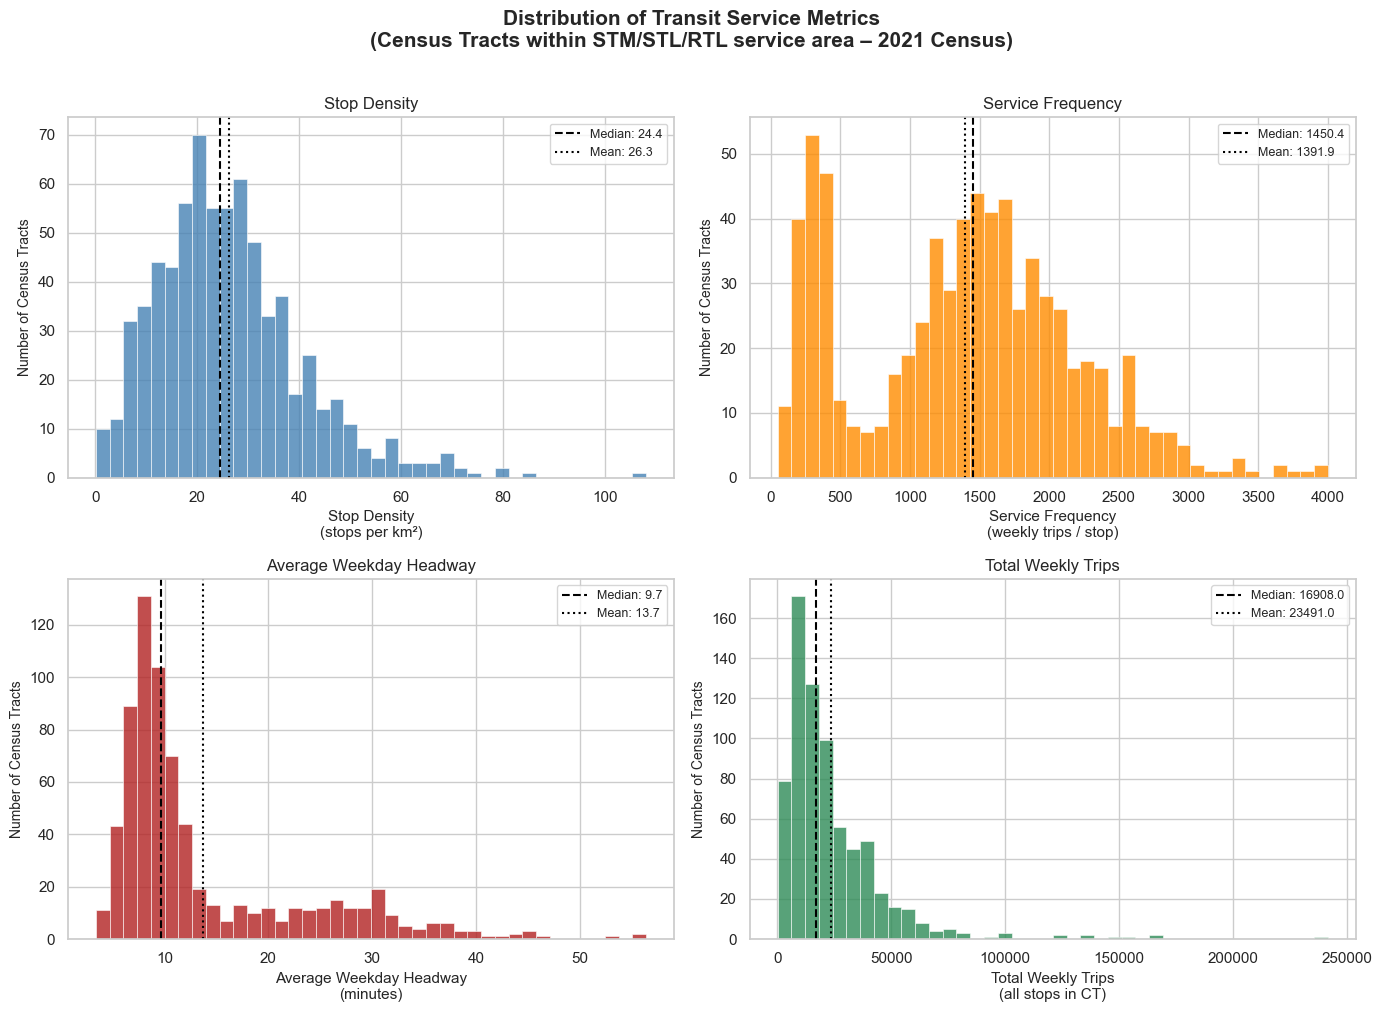

✅ Saved: figures/fig1_transit_distributions.png


In [348]:
# Distribution plots: transit service metrics (served CTs only) ─────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribution of Transit Service Metrics\n'
             '(Census Tracts within STM/STL/RTL service area – 2021 Census)',
             fontsize=15, fontweight='bold', y=1.01)

plot_vars = [
    ('stop_density',      'Stop Density\n(stops per km²)',           'steelblue'),
    ('trips_per_stop',    'Service Frequency\n(weekly trips / stop)', 'darkorange'),
    ('avg_headway_min',   'Average Weekday Headway\n(minutes)',       'firebrick'),
    ('total_weekly_trips','Total Weekly Trips\n(all stops in CT)',    'seagreen'),
]

for ax, (col, label, color) in zip(axes.flat, plot_vars):
    data = master_served[col].dropna()

    ax.hist(data, bins=40, color=color, alpha=0.8, edgecolor='white', linewidth=0.5)
    ax.axvline(data.median(), color='black', linestyle='--',
               linewidth=1.5, label=f'Median: {data.median():.1f}')
    ax.axvline(data.mean(),   color='black', linestyle=':',
               linewidth=1.5, label=f'Mean: {data.mean():.1f}')
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel('Number of Census Tracts', fontsize=10)
    ax.legend(fontsize=9)
    ax.set_title(label.split('\n')[0], fontsize=12)

plt.tight_layout()
fig.savefig(os.path.join(FIGURES, 'fig1_transit_distributions.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: figures/fig1_transit_distributions.png")

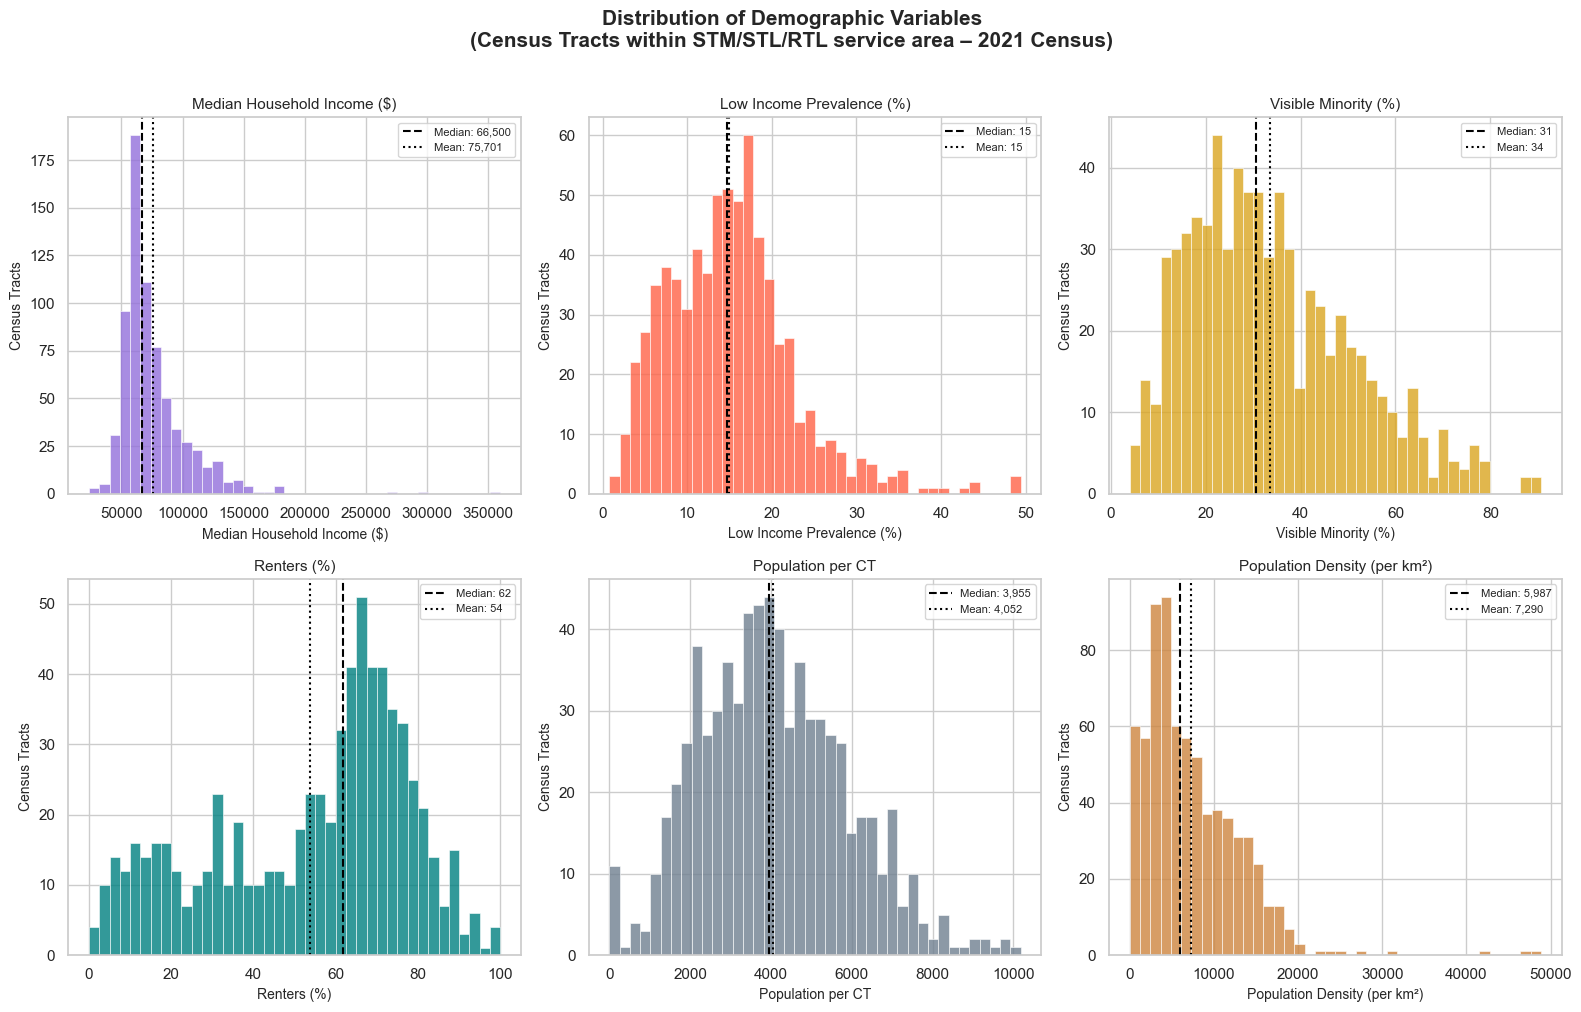

✅ Saved: figures/fig2_demographic_distributions.png


In [349]:
# Distribution plots: demographic variables (served CTs only) ───────────────

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribution of Demographic Variables\n'
             '(Census Tracts within STM/STL/RTL service area – 2021 Census)',
             fontsize=15, fontweight='bold', y=1.01)

demo_vars = [
    ('median_hh_income',     'Median Household Income ($)',  'mediumpurple'),
    ('pct_low_income',       'Low Income Prevalence (%)',     'tomato'),
    ('pct_visible_minority', 'Visible Minority (%)',          'goldenrod'),
    ('pct_renter',           'Renters (%)',                   'teal'),
    ('population',           'Population per CT',             'slategray'),
    ('pop_density',          'Population Density (per km²)',  'peru'),
]

for ax, (col, label, color) in zip(axes.flat, demo_vars):
    data = master_served[col].dropna()
    ax.hist(data, bins=40, color=color, alpha=0.8, edgecolor='white', linewidth=0.5)
    ax.axvline(data.median(), color='black', linestyle='--',
               linewidth=1.5, label=f'Median: {data.median():,.0f}')
    ax.axvline(data.mean(),   color='black', linestyle=':',
               linewidth=1.5, label=f'Mean: {data.mean():,.0f}')
    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel('Census Tracts', fontsize=10)
    ax.legend(fontsize=8)
    ax.set_title(label.split('\n')[0], fontsize=11)

plt.tight_layout()
fig.savefig(os.path.join(FIGURES, 'fig2_demographic_distributions.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: figures/fig2_demographic_distributions.png")

### 5.3. Geographic Overview

The maps below provide an initial spatial view of the data. Patterns visible here motivate the formal analysis in Section 6.

**Figure 3 (left):** Stop density across all 1,004 Montreal CMA Census Tracts. (*Where is transit infrastructure concentrated?*)  
* Grey areas outside the STM/STL/RTL footprint confirm that the three agencies collectively cover the densely populated inner core.

**Figure 3 (right):** Median household income, shown only for the STM/STL/RTL service area. (*Where are wealthier and lower-income neighbourhoods located?*)  
* Grey CTs are excluded from the analysis, since they fall outside our agencies' service territory and we have no transit data to compare against their demographics.

**Figure 4:** Average weekday headway and low-income prevalence, both within the service area only.  
* Visual alignment (or misalignment) between the headway and low-income maps is the central spatial question of this analysis.

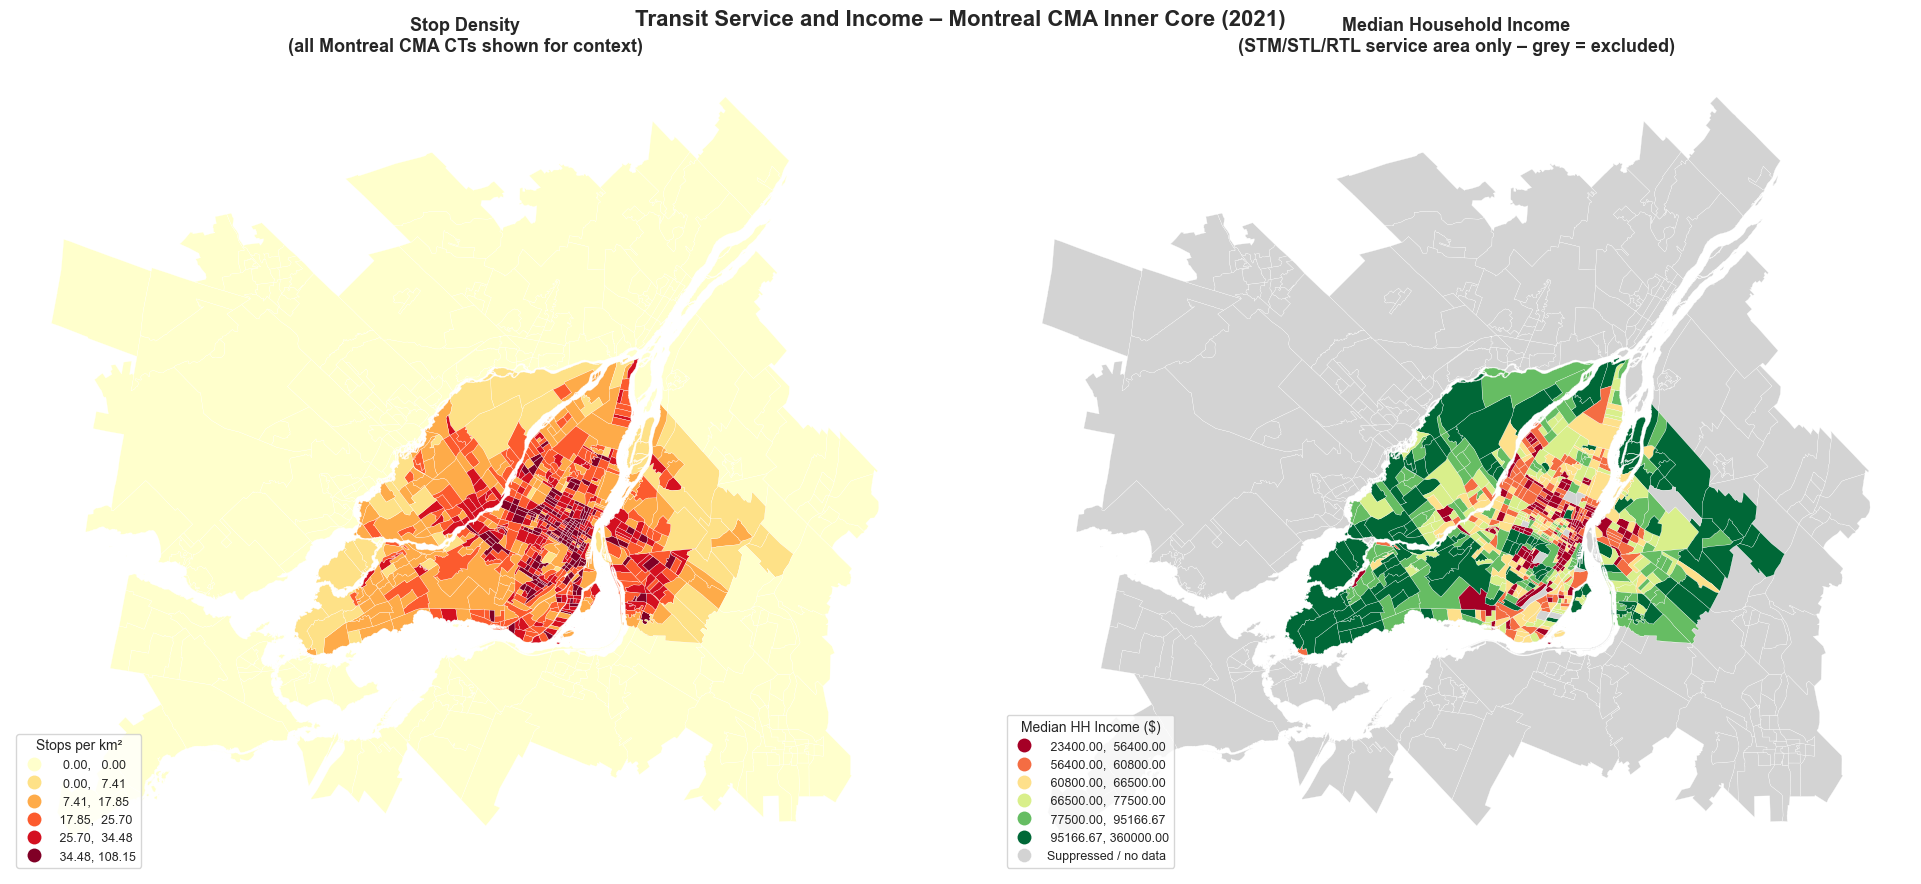

✅ Saved: figures/fig3_map_service_vs_income.png


In [350]:
# Choropleth maps: stop density and median household income ─────────────────

     # Stop density uses `master` (all CTs): zeros are geographically informative.
     # Income uses `master_served`: we only compare demographics where we have transit data.
     # Outer-suburb CTs are shown in grey.

fig, axes = plt.subplots(1, 2, figsize=(20, 9))
fig.suptitle('Transit Service and Income – Montreal CMA Inner Core (2021)',
             fontsize=16, fontweight='bold')

# Left: stop density (all CTs) ──────────────────────────────────────────────
master.plot(
    ax=axes[0],
    column='stop_density',
    cmap='YlOrRd',
    scheme='quantiles',
    k=6,
    legend=True,
    legend_kwds={
        'title': 'Stops per km²',
        'title_fontsize': 10,
        'fontsize': 9,
        'loc': 'lower left'
    },
    missing_kwds={'color': 'lightgrey', 'label': 'No stops / no data'},
    edgecolor='white',
    linewidth=0.2
)
axes[0].set_title('Stop Density\n(all Montreal CMA CTs shown for context)',
                  fontsize=13, fontweight='bold')
axes[0].set_axis_off()

# Right: median household income (served CTs only) ─────────────────────────

     # Grey CTs = outside STM/STL/RTL service footprint. They are excluded from analysis.
     # This ensures income is only shown where we have transit data to compare.

# First draw all CTs in grey as background
master.plot(ax=axes[1], color='lightgrey', edgecolor='white', linewidth=0.2)

# Then overlay only served CTs coloured by income
master_served.plot(
    ax=axes[1],
    column='median_hh_income',
    cmap='RdYlGn',
    scheme='quantiles',
    k=6,
    legend=True,
    legend_kwds={
        'title': 'Median HH Income ($)',
        'title_fontsize': 10,
        'fontsize': 9,
        'loc': 'lower left'
    },
    missing_kwds={'color': '#d3d3d3', 'label': 'Suppressed / no data'},
    edgecolor='white',
    linewidth=0.2
)
axes[1].set_title('Median Household Income\n(STM/STL/RTL service area only – grey = excluded)',
                  fontsize=13, fontweight='bold')
axes[1].set_axis_off()

plt.tight_layout()
fig.savefig(os.path.join(FIGURES, 'fig3_map_service_vs_income.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: figures/fig3_map_service_vs_income.png")

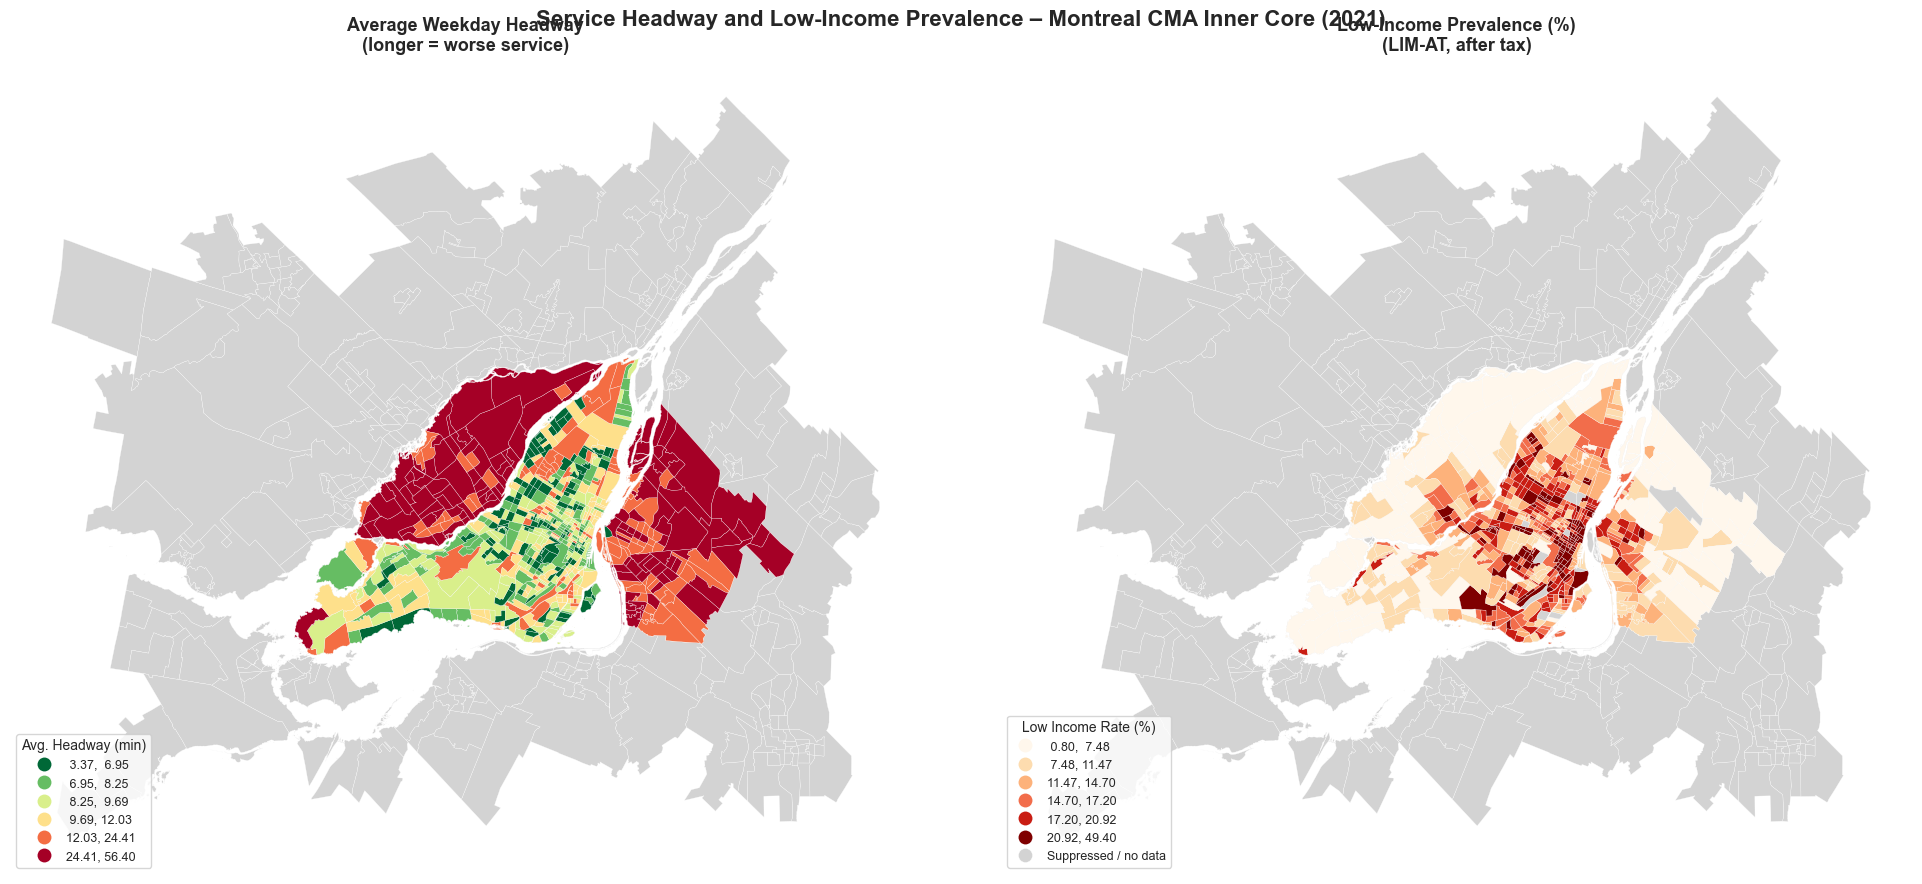

✅ Saved: figures/fig4_map_headway_vs_lowincome.png


In [351]:
# Choropleth maps: headway and low-income rate ──────────────────────────────

     # Both panels use master_served: headway is undefined outside the service footprint, and we only compare low-income rates where transit data exists.
     # Grey background shows the full CMA extent for geographic context.

fig, axes = plt.subplots(1, 2, figsize=(20, 9))
fig.suptitle('Service Headway and Low-Income Prevalence – Montreal CMA Inner Core (2021)',
             fontsize=16, fontweight='bold')

for ax in axes:
    master.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.2)

# Left: average weekday headway (served CTs only) ───────────────────────────
master_served.plot(
    ax=axes[0],
    column='avg_headway_min',
    cmap='RdYlGn_r',
    scheme='quantiles',
    k=6,
    legend=True,
    legend_kwds={
        'title': 'Avg. Headway (min)',
        'title_fontsize': 10,
        'fontsize': 9,
        'loc': 'lower left'
    },
    missing_kwds={'color': '#d3d3d3', 'label': 'No data'},
    edgecolor='white',
    linewidth=0.2
)
axes[0].set_title('Average Weekday Headway\n(longer = worse service)',
                  fontsize=13, fontweight='bold')
axes[0].set_axis_off()

# Right: low-income prevalence (served CTs only) ────────────────────────────
master_served.plot(
    ax=axes[1],
    column='pct_low_income',
    cmap='OrRd',
    scheme='quantiles',
    k=6,
    legend=True,
    legend_kwds={
        'title': 'Low Income Rate (%)',
        'title_fontsize': 10,
        'fontsize': 9,
        'loc': 'lower left'
    },
    missing_kwds={'color': '#d3d3d3', 'label': 'Suppressed / no data'},
    edgecolor='white',
    linewidth=0.2
)
axes[1].set_title('Low-Income Prevalence (%)\n(LIM-AT, after tax)',
                  fontsize=13, fontweight='bold')
axes[1].set_axis_off()

plt.tight_layout()
fig.savefig(os.path.join(FIGURES, 'fig4_map_headway_vs_lowincome.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: figures/fig4_map_headway_vs_lowincome.png")

### 5.4. Transit Service by Income Quintile

We now ask a direct question: does transit service vary systematically across the income spectrum?

Census Tracts are divided into 5 equal-size groups (quintiles) by `median_hh_income`, across which we compare average transit service metrics. If transit is equitably distributed, bars should be roughly equal. If lower-income areas are underserved, bars should rise from Q1 to Q5.

Mean transit service metrics by income quintile:



,n_cts,median_income,mean_stop_density,mean_trips_per_stop,mean_headway,mean_pct_low_income
income_quintile,,,,,,
Q1\n(Lowest),141,52800.00,35.14,1823.29,10.12,25.07
Q2,153,60400.00,29.27,1522.54,12.10,17.43
Q3,128,67000.00,28.13,1526.62,11.53,15.12
Q4,139,80000.00,24.03,1129.24,15.81,10.66
Q5\n(Highest),141,110000.00,15.54,932.52,19.20,6.42


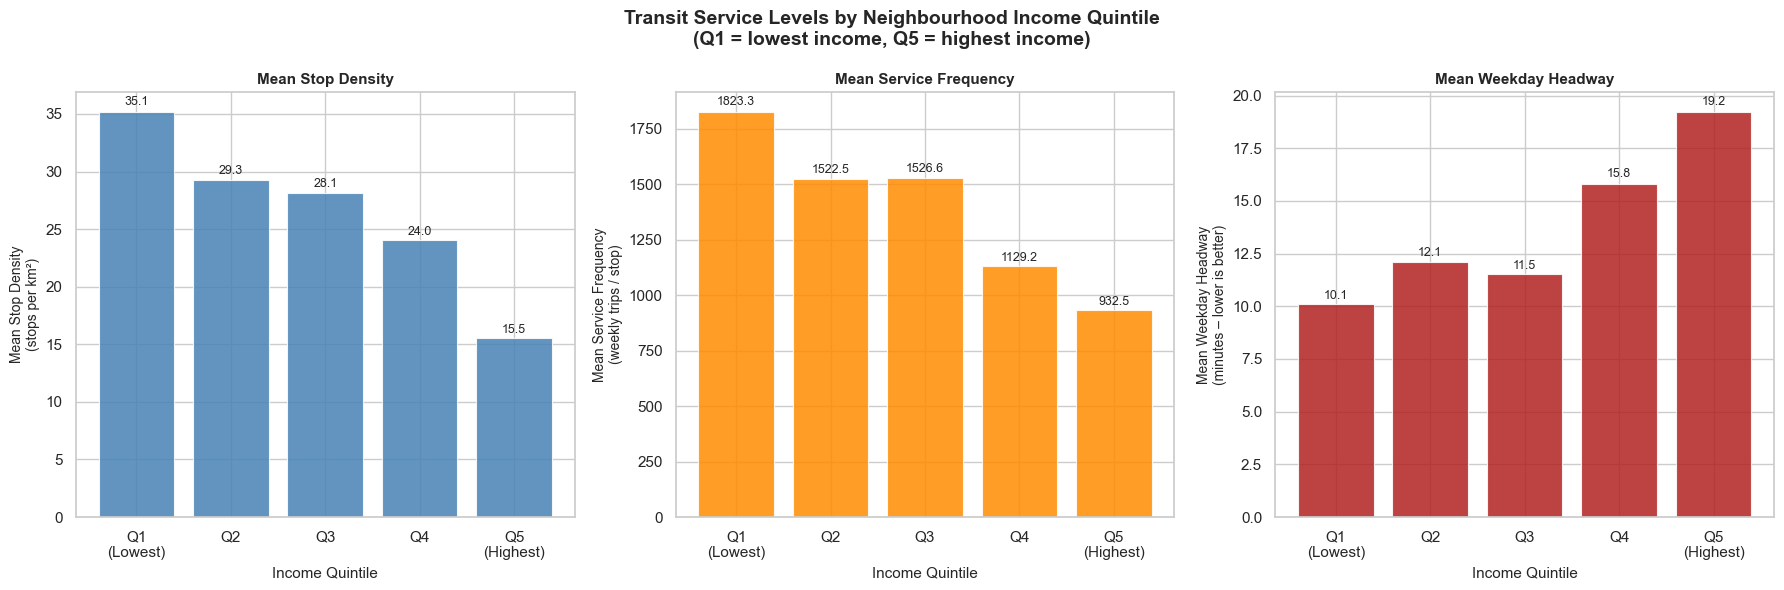

✅ Saved: figures/fig5_service_by_income_quintile.png


In [352]:
# Transit service by income quintile ────────────────────────────────────────

# Use master_served, already filtered to STM/STL/RTL service footprint.
master_q = master_served.dropna(subset=['median_hh_income', 'stop_density']).copy()

master_q['income_quintile'] = pd.qcut(
    master_q['median_hh_income'],
    q=5,
    labels=['Q1\n(Lowest)', 'Q2', 'Q3', 'Q4', 'Q5\n(Highest)']
)

# Summary table ─────────────────────────────────────────────────────────────
quintile_summary = (
    master_q.groupby('income_quintile', observed=True)
    .agg(
        n_cts=('DGUID', 'count'),
        median_income=('median_hh_income', 'median'),
        mean_stop_density=('stop_density', 'mean'),
        mean_trips_per_stop=('trips_per_stop', 'mean'),
        mean_headway=('avg_headway_min', 'mean'),
        mean_pct_low_income=('pct_low_income', 'mean')
    )
    .round(2)
)

print("Mean transit service metrics by income quintile:\n")
display(quintile_summary)

# Bar chart ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Transit Service Levels by Neighbourhood Income Quintile\n'
             '(Q1 = lowest income, Q5 = highest income)',
             fontsize=14, fontweight='bold')

metrics = [
    ('mean_stop_density',   'Mean Stop Density\n(stops per km²)',     'steelblue'),
    ('mean_trips_per_stop', 'Mean Service Frequency\n(weekly trips / stop)', 'darkorange'),
    ('mean_headway',        'Mean Weekday Headway\n(minutes – lower is better)', 'firebrick'),
]

for ax, (metric, ylabel, color) in zip(axes, metrics):
    bars = ax.bar(
        quintile_summary.index,
        quintile_summary[metric],
        color=color,
        alpha=0.85,
        edgecolor='white',
        linewidth=0.8
    )
    # Value labels on top of each bar
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h * 1.01,
                f'{h:.1f}', ha='center', va='bottom', fontsize=9)
    ax.set_xlabel('Income Quintile', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(ylabel.split('\n')[0], fontsize=11, fontweight='bold')

plt.tight_layout()
fig.savefig(os.path.join(FIGURES, 'fig5_service_by_income_quintile.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: figures/fig5_service_by_income_quintile.png")

### 5.5. EDA Summary

The exploratory analysis of the STM/STL/RTL service area surfaces several patterns that motivate the formal analysis in Section 6.

**Service distribution:**
- Transit service metrics are right-skewed across the service area: a smaller number of Census Tracts concentrated in the urban core of Montreal island have very high stop density and trip frequency, while the majority of CTs in Laval and the South Shore have more moderate levels.
- Average weekday headway is similarly distributed, with the lowest headways (most frequent service) concentrated in the city centre.

**Geography:**
- The stop density map confirms that the 3 agencies collectively form a coherent service area across the inner CMA, with no unexpected gaps in coverage within their territories.
- Comparing the stop density and income maps, some spatial mismatch is visible: certain peripheral CTs within the service area show lower stop density alongside lower median household income. This is a pattern worth testing formally.

**Income quintiles:**
- Transit service does not rise uniformly with income across the service area. The relationship is non-linear and requires formal statistical testing to characterize.
- Lower-income quintiles are not consistently the worst-served, likely because many low-income CTs are centrally located on Montreal island where service density is highest.
- The *suburban* dimension (income + distance from core) may be the stronger predictor of service level. This will be examined in the regression analysis.

These observations frame the hypotheses tested in Section 6.